# AI Agent Workflow Observability & Performance Optimization
### Enterprise AI Support Operations Analytics

---

**Author:** UC Berkeley Data Science  
**Dataset:** 400 synthetic support tickets · 7 issue categories · 90-day window  
**Tools:** Python · NumPy · Pandas · Matplotlib · Seaborn

---

This notebook analyzes how an AI agent performs inside an enterprise customer support workflow. The focus is not the AI model itself, but the **operational system around it**: routing decisions, escalation behavior, SLA compliance, cost tradeoffs, and customer impact.

**Contents**

| Section | Topic |
|---|---|
| 1 | Business Problem & Workflow Architecture |
| 2 | Data Generation |
| 3 | Data Cleaning & Validation |
| 4 | KPI Dashboard |
| 5 | Visualizations (10 charts) |
| 6 | Key Findings |
| 7 | Business Recommendations |
| 8 | Export |


---
## Section 0: Setup

Imports, plot style, and display settings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from datetime import datetime, timedelta
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

# Plot style
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")

# Display options
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)

# Color palette (used throughout)
BLUE       = "#2E6DA4"
ORANGE     = "#E07B39"
RED        = "#C0392B"
GREEN      = "#27AE60"
GRAY       = "#7F8C8D"
LIGHT_BLUE = "#AED6F1"
DARK_BLUE  = "#1A3A5C"
YELLOW     = "#F1C40F"

print("Setup complete.")

Setup complete.


---
## Section 1: Business Problem

Companies deploy AI agents to reduce support workload and accelerate resolution times. The operational challenge is not whether AI can handle tickets — it is understanding **where it fails, how often, at what cost, and with what impact on customers.** Without structured observability, organizations run AI systems that appear performant in aggregate while silently degrading on specific issue types or customer segments.

### Workflow Architecture

```
Customer submits ticket
       │
       ▼
AI classifies issue & generates response
       │
       ▼
System evaluates confidence score
       │
       ├── High (≥ 0.80)  ──► AI handles directly  ──► Customer rating
       ├── Medium (0.60–0.79) ──► Routing decision
       └── Low  (< 0.60)  ──► Escalate to human  ──► Resolution
                                        │
                                        ▼
                           Operations team monitors KPIs
```

### System Boundary

This project does **not** attempt to fully automate customer support. The goal is to analyze where AI agents can operate safely, where human governance is required, and how organizations can monitor the tradeoffs between cost, speed, reliability, and customer satisfaction.

---
## Section 2: Data Generation

The dataset is generated in-memory using `numpy` with `seed=42` for full reproducibility. Correlations are baked in by design: technical support draws from a lower confidence distribution, low-confidence tickets have elevated escalation and hallucination probabilities, and escalated tickets carry a higher cost structure. The result is a 400-row dataset with 22 columns that mirrors the statistical behavior of a real enterprise support workflow.

In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Constants ────────────────────────────────────────────────────────────────
N = 400
BASE_DATE  = datetime(2026, 5, 20)
START_DATE = BASE_DATE - timedelta(days=90)

CUSTOMER_TIERS    = ["bronze", "silver", "gold", "enterprise"]
ISSUE_CATEGORIES  = [
    "billing", "refund", "shipping", "login",
    "account_access", "technical_support", "subscription_cancellation"
]
PRIORITY_LEVELS   = ["low", "medium", "high", "critical"]
SLA_TARGETS       = {"low": 1440, "medium": 240, "high": 60, "critical": 60}

# ── Ticket IDs & User IDs ────────────────────────────────────────────────────
ticket_ids = [f"TKT-{str(i).zfill(5)}" for i in range(1, N + 1)]
user_ids   = [f"USR-{np.random.randint(1000, 9999)}" for _ in range(N)]

# ── Timestamps ───────────────────────────────────────────────────────────────
seconds_in_90_days = 90 * 24 * 3600
random_offsets     = np.random.randint(0, seconds_in_90_days, size=N)
timestamps         = [START_DATE + timedelta(seconds=int(s)) for s in random_offsets]

# ── Customer Tier ────────────────────────────────────────────────────────────
tier_weights  = [0.35, 0.30, 0.22, 0.13]  # bronze, silver, gold, enterprise
customer_tier = np.random.choice(CUSTOMER_TIERS, size=N, p=tier_weights)

# ── Issue Category ───────────────────────────────────────────────────────────
category_weights = [0.18, 0.13, 0.12, 0.16, 0.14, 0.17, 0.10]
issue_category   = np.random.choice(ISSUE_CATEGORIES, size=N, p=category_weights)

# ── Priority Level (enterprise/gold → higher priority) ───────────────────────
priority_level = []
for tier in customer_tier:
    if tier == "enterprise":
        p = [0.05, 0.25, 0.45, 0.25]
    elif tier == "gold":
        p = [0.10, 0.30, 0.40, 0.20]
    elif tier == "silver":
        p = [0.25, 0.40, 0.25, 0.10]
    else:  # bronze
        p = [0.40, 0.35, 0.18, 0.07]
    priority_level.append(np.random.choice(PRIORITY_LEVELS, p=p))
priority_level = np.array(priority_level)

# ── AI Confidence Score (category-dependent) ─────────────────────────────────
CONFIDENCE_PARAMS = {
    "technical_support":           (0.55, 0.15),
    "billing":                     (0.65, 0.14),
    "account_access":              (0.65, 0.13),
    "login":                       (0.75, 0.12),
    "shipping":                    (0.75, 0.11),
    "refund":                      (0.70, 0.13),
    "subscription_cancellation":   (0.70, 0.14),
}
ai_confidence_score = np.array([
    np.clip(np.random.normal(*CONFIDENCE_PARAMS[cat]), 0.01, 0.99)
    for cat in issue_category
])

# ── AI Correct Response ───────────────────────────────────────────────────────
ai_correct_prob     = np.clip(ai_confidence_score * 1.1 - 0.05, 0.10, 0.97)
ai_correct_response = np.random.random(N) < ai_correct_prob

# ── Routing Decision & Correctness ───────────────────────────────────────────
escalation_prob = np.where(
    ai_confidence_score < 0.6, 0.70,
    np.where(ai_confidence_score >= 0.8, 0.15, 0.35)
)
escalated_flag   = np.random.random(N) < escalation_prob
routing_decision = np.where(escalated_flag, "escalated_to_human", "ai_handled")
routing_correct  = np.random.random(N) < 0.85

# ── Hallucination ─────────────────────────────────────────────────────────────
hallucination_prob = np.where(ai_confidence_score < 0.6, 0.12, 0.03)
hallucination_flag = np.random.random(N) < hallucination_prob

# ── Retry Count ───────────────────────────────────────────────────────────────
retry_count = np.array([
    np.random.choice([0, 1, 2, 3],
                     p=[0.40, 0.30, 0.20, 0.10] if c < 0.6 else [0.65, 0.22, 0.10, 0.03])
    for c in ai_confidence_score
])

# ── Failure Type ──────────────────────────────────────────────────────────────
def assign_failure_type(conf, halluc, routed_correct, retries):
    if halluc:
        return "hallucination"
    if not routed_correct:
        return "routing_failure"
    if retries >= 2:
        return "timeout" if np.random.random() < 0.5 else "low_confidence"
    if conf < 0.6 and np.random.random() < 0.25:
        return "low_confidence"
    return "none"

failure_type = np.array([
    assign_failure_type(ai_confidence_score[i], hallucination_flag[i],
                        routing_correct[i], retry_count[i])
    for i in range(N)
])

# ── Response Time (seconds) ───────────────────────────────────────────────────
base_response = np.where(
    escalated_flag,
    np.random.normal(45, 15, N),
    np.random.normal(8, 4, N)
)
response_time_seconds = np.clip(base_response, 2, 180).astype(int)

# ── Escalation Required & Escalated to Human ─────────────────────────────────
escalation_required = escalated_flag.copy()
escalated_to_human  = np.where(
    escalation_required,
    np.random.random(N) < 0.95,
    False
)

# ── Human Resolution Time ─────────────────────────────────────────────────────
human_resolution_time_minutes = np.where(
    escalated_to_human,
    np.clip(np.random.lognormal(mean=3.8, sigma=0.7, size=N), 10, 480),
    np.nan
)

# ── Total Resolution Time ─────────────────────────────────────────────────────
ai_resolution_minutes = np.clip(
    np.random.lognormal(mean=2.5, sigma=0.6, size=N), 2, 90
)
total_resolution_time_minutes = np.where(
    escalated_to_human,
    (response_time_seconds / 60) + human_resolution_time_minutes,
    ai_resolution_minutes
)

# ── SLA Breach ────────────────────────────────────────────────────────────────
sla_target_minutes = np.array([SLA_TARGETS[p] for p in priority_level])
sla_breached       = total_resolution_time_minutes > sla_target_minutes

# ── Repeat Issue ──────────────────────────────────────────────────────────────
repeat_base = 0.18
repeat_prob = np.where(hallucination_flag, repeat_base + 0.10, repeat_base)
repeat_issue = np.random.random(N) < repeat_prob

# ── Customer Rating ───────────────────────────────────────────────────────────
rating_base  = np.full(N, 3.8)
rating_base += np.where(ai_correct_response, 0.5, 0.0)
rating_base -= np.where(hallucination_flag,  0.7, 0.0)
rating_base -= np.where(sla_breached,        0.4, 0.0)
rating_base -= np.where(repeat_issue,        0.3, 0.0)
rating_base += np.random.normal(0, 0.25, N)
customer_rating = np.clip(rating_base, 1.0, 5.0).round(1)

# ── Estimated Cost Per Ticket ─────────────────────────────────────────────────
estimated_cost_per_ticket = np.where(
    escalated_to_human,
    np.random.uniform(18, 35, N),
    np.random.uniform(5, 12, N)
).round(2)

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    "ticket_id":                     ticket_ids,
    "user_id":                       user_ids,
    "timestamp":                     timestamps,
    "customer_tier":                 customer_tier,
    "issue_category":                issue_category,
    "priority_level":                priority_level,
    "ai_confidence_score":           ai_confidence_score.round(4),
    "ai_correct_response":           ai_correct_response,
    "routing_decision":              routing_decision,
    "routing_correct":               routing_correct,
    "response_time_seconds":         response_time_seconds,
    "escalation_required":           escalation_required,
    "escalated_to_human":            escalated_to_human,
    "human_resolution_time_minutes": human_resolution_time_minutes.round(2),
    "total_resolution_time_minutes": total_resolution_time_minutes.round(2),
    "hallucination_flag":            hallucination_flag,
    "retry_count":                   retry_count,
    "failure_type":                  failure_type,
    "customer_rating":               customer_rating,
    "repeat_issue":                  repeat_issue,
    "sla_breached":                  sla_breached,
    "estimated_cost_per_ticket":     estimated_cost_per_ticket,
})

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (400, 22)
Columns: ['ticket_id', 'user_id', 'timestamp', 'customer_tier', 'issue_category', 'priority_level', 'ai_confidence_score', 'ai_correct_response', 'routing_decision', 'routing_correct', 'response_time_seconds', 'escalation_required', 'escalated_to_human', 'human_resolution_time_minutes', 'total_resolution_time_minutes', 'hallucination_flag', 'retry_count', 'failure_type', 'customer_rating', 'repeat_issue', 'sla_breached', 'estimated_cost_per_ticket']


,ticket_id,user_id,timestamp,customer_tier,issue_category,priority_level,ai_confidence_score,ai_correct_response,routing_decision,routing_correct,response_time_seconds,escalation_required,escalated_to_human,human_resolution_time_minutes,total_resolution_time_minutes,hallucination_flag,retry_count,failure_type,customer_rating,repeat_issue,sla_breached,estimated_cost_per_ticket
0,TKT-00001,USR-8270,2026-05-19 06:20:02,bronze,account_access,low,0.4949,False,escalated_to_human,True,43,True,True,81.1800,81.9000,False,3,low_confidence,3.7000,False,False,18.5700
1,TKT-00002,USR-1860,2026-04-18 19:32:09,bronze,refund,medium,0.6948,False,ai_handled,True,3,False,False,NaN,23.8400,False,1,none,3.4000,False,False,7.1400
2,TKT-00003,USR-6390,2026-04-11 16:37:51,bronze,shipping,medium,0.8785,True,ai_handled,False,6,False,False,NaN,10.2100,False,0,routing_failure,4.6000,False,False,11.8200
3,TKT-00004,USR-6191,2026-04-10 18:12:16,silver,refund,high,0.5878,True,ai_handled,True,7,False,False,NaN,29.1300,False,0,low_confidence,4.2000,False,False,9.6400
4,TKT-00005,USR-6734,2026-03-06 15:44:55,silver,shipping,low,0.4967,True,ai_handled,True,2,False,False,NaN,30.4900,False,1,none,4.0000,False,False,7.8600


In [3]:
df.describe()

,timestamp,ai_confidence_score,response_time_seconds,human_resolution_time_minutes,total_resolution_time_minutes,retry_count,customer_rating,estimated_cost_per_ticket
count,400,400.0000,400.0000,155.0000,400.0000,400.0000,400.0000,400.0000
mean,2026-04-05 14:40:19.372499968,0.6675,22.2500,54.7330,30.4105,0.6400,4.0235,15.2350
min,2026-02-19 00:06:44,0.1193,2.0000,10.0000,3.5100,0.0000,2.2000,5.0000
25%,2026-03-16 23:18:20,0.5845,7.0000,27.9600,10.6775,0.0000,3.7000,7.8575
50%,2026-04-06 21:36:59.500000,0.6722,12.0000,44.2600,18.5250,0.0000,4.1000,10.6850
75%,2026-04-24 08:22:13.750000128,0.7599,41.0000,69.9200,38.7025,1.0000,4.3000,22.7025
max,2026-05-19 23:53:16,0.9900,82.0000,230.5700,231.4400,3.0000,5.0000,34.8700
std,NaN,0.1377,20.0170,37.0052,31.4494,0.8873,0.4148,9.1865


---
## Section 3: Data Cleaning & Validation

This section coerces column types, validates value ranges, and adds three derived columns: `confidence_band` (low / medium / high), `resolution_speed` (fast / moderate / slow), and `cost_tier` (low / medium / high). A data quality report is printed inline.

In [4]:
# ── Type Coercion ─────────────────────────────────────────────────────────────
bool_cols = [
    "ai_correct_response", "routing_correct", "escalation_required",
    "escalated_to_human", "hallucination_flag", "repeat_issue", "sla_breached"
]
for col in bool_cols:
    df[col] = df[col].astype(bool)

int_cols = ["response_time_seconds", "retry_count"]
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

float_cols = [
    "ai_confidence_score", "human_resolution_time_minutes",
    "total_resolution_time_minutes", "customer_rating", "estimated_cost_per_ticket"
]
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Range Validation ──────────────────────────────────────────────────────────
issues = []
def check(cond, msg):
    if not cond:
        issues.append(msg)

check(df["ai_confidence_score"].between(0.0, 1.0).all(),  "ai_confidence_score out of [0,1]")
check(df["customer_rating"].between(1.0, 5.0).all(),       "customer_rating out of [1,5]")
check(df["retry_count"].dropna().between(0, 3).all(),      "retry_count out of [0,3]")
check(df["estimated_cost_per_ticket"].gt(0).all(),         "non-positive cost values found")
check(df["response_time_seconds"].dropna().gt(0).all(),    "non-positive response time found")

# ── Categorical Validation ────────────────────────────────────────────────────
valid_tiers      = {"bronze", "silver", "gold", "enterprise"}
valid_categories = {
    "billing", "refund", "shipping", "login",
    "account_access", "technical_support", "subscription_cancellation"
}
valid_priorities = {"low", "medium", "high", "critical"}
valid_routing    = {"ai_handled", "escalated_to_human"}
valid_failures   = {"none", "routing_failure", "hallucination", "timeout", "low_confidence"}

check(set(df["customer_tier"].unique()).issubset(valid_tiers),          "unexpected customer_tier values")
check(set(df["issue_category"].unique()).issubset(valid_categories),     "unexpected issue_category values")
check(set(df["priority_level"].unique()).issubset(valid_priorities),     "unexpected priority_level values")
check(set(df["routing_decision"].unique()).issubset(valid_routing),      "unexpected routing_decision values")
check(set(df["failure_type"].unique()).issubset(valid_failures),         "unexpected failure_type values")

# ── Missing Value Audit ───────────────────────────────────────────────────────
non_esc_nan = df.loc[~df["escalated_to_human"], "human_resolution_time_minutes"].isna().all()
check(non_esc_nan, "human_resolution_time_minutes unexpectedly non-NaN for non-escalated tickets")

other_cols = [c for c in df.columns if c != "human_resolution_time_minutes"]
for col in other_cols:
    null_count = df[col].isna().sum()
    if null_count > 0:
        issues.append(f"Unexpected nulls in '{col}': {null_count} rows")

# ── Derived Columns ───────────────────────────────────────────────────────────
df["confidence_band"] = pd.cut(
    df["ai_confidence_score"],
    bins=[-np.inf, 0.6, 0.8, np.inf],
    labels=["low", "medium", "high"]
).astype(str)

df["resolution_speed"] = pd.cut(
    df["total_resolution_time_minutes"],
    bins=[-np.inf, 30, 120, np.inf],
    labels=["fast", "moderate", "slow"]
).astype(str)

df["cost_tier"] = pd.cut(
    df["estimated_cost_per_ticket"],
    bins=[-np.inf, 10, 20, np.inf],
    labels=["low_cost", "medium_cost", "high_cost"]
).astype(str)

df["day_of_week"] = pd.to_datetime(df["timestamp"]).dt.day_name()
df["hour_of_day"] = pd.to_datetime(df["timestamp"]).dt.hour

# Ordered categoricals
df["priority_level"] = pd.Categorical(
    df["priority_level"],
    categories=["low", "medium", "high", "critical"],
    ordered=True
)
df["customer_tier"] = pd.Categorical(
    df["customer_tier"],
    categories=["bronze", "silver", "gold", "enterprise"],
    ordered=True
)

# ── Quality Summary Table ─────────────────────────────────────────────────────
quality_rows = []
for col in df.columns:
    quality_rows.append({
        "Column": col,
        "Dtype":  str(df[col].dtype),
        "Non-Null": int(df[col].notna().sum()),
        "Null":     int(df[col].isna().sum()),
    })
quality_df = pd.DataFrame(quality_rows)

print(f"Validation issues found: {len(issues)}")
if issues:
    for iss in issues:
        print(f"  WARNING: {iss}")
else:
    print("  All validation checks passed.")

print(f"\nFinal dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nData Quality Summary:")
display(quality_df)

Validation issues found: 0
  All validation checks passed.

Final dataset shape: 400 rows x 27 columns

Data Quality Summary:


,Column,Dtype,Non-Null,Null
0,ticket_id,object,400,0
1,user_id,object,400,0
2,timestamp,datetime64[ns],400,0
3,customer_tier,category,400,0
4,issue_category,object,400,0
5,priority_level,category,400,0
6,ai_confidence_score,float64,400,0
7,ai_correct_response,bool,400,0
8,routing_decision,object,400,0
9,routing_correct,bool,400,0


**Note on missing values:** `human_resolution_time_minutes` is `NaN` for the 245 tickets that were handled entirely by AI — these are not data gaps. Only the 155 escalated tickets have a valid human resolution time. All downstream analysis filters on `escalated_to_human` before using this column.

---
## Section 4: KPI Dashboard

Twenty-two KPIs are computed across four categories: AI reliability, workflow efficiency, customer satisfaction, and business cost. The table below is color-coded by operational status — **Good**, **Monitor**, or **Critical** — to give operations leadership an at-a-glance health check.

In [5]:
# ── AI / Reliability KPIs ─────────────────────────────────────────────────────
ai_accuracy_rate         = df["ai_correct_response"].mean()
hallucination_rate       = df["hallucination_flag"].mean()
low_confidence_rate      = (df["ai_confidence_score"] < 0.6).mean()
routing_accuracy_rate    = df["routing_correct"].mean()
retry_rate               = (df["retry_count"] > 0).mean()
avg_confidence_score     = df["ai_confidence_score"].mean()

# ── Workflow KPIs ─────────────────────────────────────────────────────────────
escalation_rate          = df["escalated_to_human"].mean()
escalation_required_rate = df["escalation_required"].mean()
avg_total_resolution     = df["total_resolution_time_minutes"].mean()
avg_human_resolution     = df.loc[df["escalated_to_human"], "human_resolution_time_minutes"].mean()
sla_breach_rate          = df["sla_breached"].mean()
repeat_issue_rate        = df["repeat_issue"].mean()

# ── Customer KPIs ─────────────────────────────────────────────────────────────
avg_customer_rating      = df["customer_rating"].mean()
rating_escalated         = df.loc[df["escalated_to_human"],  "customer_rating"].mean()
rating_not_escalated     = df.loc[~df["escalated_to_human"], "customer_rating"].mean()
rating_by_category       = df.groupby("issue_category")["customer_rating"].mean().round(3)

# ── Business KPIs ─────────────────────────────────────────────────────────────
avg_cost_overall         = df["estimated_cost_per_ticket"].mean()
avg_cost_escalated       = df.loc[df["escalated_to_human"],  "estimated_cost_per_ticket"].mean()
avg_cost_not_escalated   = df.loc[~df["escalated_to_human"], "estimated_cost_per_ticket"].mean()
total_cost_escalated     = df.loc[df["escalated_to_human"],  "estimated_cost_per_ticket"].sum()
total_cost_not_escalated = df.loc[~df["escalated_to_human"], "estimated_cost_per_ticket"].sum()
total_cost_overall       = df["estimated_cost_per_ticket"].sum()
cost_multiplier          = avg_cost_escalated / avg_cost_not_escalated

# ── Display Dashboard ─────────────────────────────────────────────────────────
kpi_html = """
<style>
  .kpi-table {{ border-collapse: collapse; width: 100%; font-family: 'Segoe UI', sans-serif; font-size: 13px; }}
  .kpi-table th {{ background: #1A3A5C; color: white; padding: 8px 14px; text-align: left; }}
  .kpi-table td {{ padding: 7px 14px; border-bottom: 1px solid #e0e0e0; }}
  .kpi-table tr:nth-child(even) {{ background: #f7f9fb; }}
  .section-header {{ background: #2E6DA4 !important; color: white !important; font-weight: bold; }}
  .good   {{ color: #27AE60; font-weight: bold; }}
  .warn   {{ color: #E07B39; font-weight: bold; }}
  .crit   {{ color: #C0392B; font-weight: bold; }}
</style>
<table class='kpi-table'>
  <tr><th>KPI</th><th>Value</th><th>Status</th></tr>

  <tr><td colspan='3' class='section-header'>AI Reliability</td></tr>
  <tr><td>AI Accuracy Rate</td><td>{:.1f}%</td><td class='good'>Good</td></tr>
  <tr><td>Hallucination Rate</td><td>{:.1f}%</td><td class='warn'>Monitor</td></tr>
  <tr><td>Low-Confidence Rate (&lt;0.6)</td><td>{:.1f}%</td><td class='warn'>Monitor</td></tr>
  <tr><td>Routing Accuracy Rate</td><td>{:.1f}%</td><td class='good'>Good</td></tr>
  <tr><td>Retry Rate</td><td>{:.1f}%</td><td class='warn'>Monitor</td></tr>
  <tr><td>Avg AI Confidence Score</td><td>{:.3f}</td><td class='warn'>Monitor</td></tr>

  <tr><td colspan='3' class='section-header'>Workflow Efficiency</td></tr>
  <tr><td>Escalation Rate</td><td>{:.1f}%</td><td class='warn'>Monitor</td></tr>
  <tr><td>Escalation Required Rate</td><td>{:.1f}%</td><td class='warn'>Monitor</td></tr>
  <tr><td>Avg Total Resolution Time</td><td>{:.1f} min</td><td class='warn'>Monitor</td></tr>
  <tr><td>Avg Human Resolution Time (escalated)</td><td>{:.1f} min</td><td class='warn'>Monitor</td></tr>
  <tr><td>SLA Breach Rate</td><td>{:.1f}%</td><td class='crit'>Critical</td></tr>
  <tr><td>Repeat Issue Rate</td><td>{:.1f}%</td><td class='warn'>Monitor</td></tr>

  <tr><td colspan='3' class='section-header'>Customer Satisfaction</td></tr>
  <tr><td>Avg Customer Rating (Overall)</td><td>{:.2f} / 5.0</td><td class='good'>Good</td></tr>
  <tr><td>Avg Rating (Escalated)</td><td>{:.2f} / 5.0</td><td class='warn'>Monitor</td></tr>
  <tr><td>Avg Rating (AI-Handled)</td><td>{:.2f} / 5.0</td><td class='good'>Good</td></tr>

  <tr><td colspan='3' class='section-header'>Business Cost</td></tr>
  <tr><td>Avg Cost Per Ticket (Overall)</td><td>${:.2f}</td><td class='warn'>Monitor</td></tr>
  <tr><td>Avg Cost Per Ticket (Escalated)</td><td>${:.2f}</td><td class='crit'>Critical</td></tr>
  <tr><td>Avg Cost Per Ticket (AI-Handled)</td><td>${:.2f}</td><td class='good'>Good</td></tr>
  <tr><td>Escalation Cost Multiplier</td><td>{:.1f}x</td><td class='crit'>Critical</td></tr>
  <tr><td>Total Cost — Escalated Tickets</td><td>${:,.2f}</td><td class='crit'>Critical</td></tr>
  <tr><td>Total Cost — AI-Handled Tickets</td><td>${:,.2f}</td><td class='good'>Good</td></tr>
  <tr><td>Total Cost — All Tickets</td><td>${:,.2f}</td><td class='warn'>Monitor</td></tr>
</table>
""".format(
    ai_accuracy_rate * 100, hallucination_rate * 100, low_confidence_rate * 100,
    routing_accuracy_rate * 100, retry_rate * 100, avg_confidence_score,
    escalation_rate * 100, escalation_required_rate * 100,
    avg_total_resolution, avg_human_resolution,
    sla_breach_rate * 100, repeat_issue_rate * 100,
    avg_customer_rating, rating_escalated, rating_not_escalated,
    avg_cost_overall, avg_cost_escalated, avg_cost_not_escalated, cost_multiplier,
    total_cost_escalated, total_cost_not_escalated, total_cost_overall
)

display(HTML(kpi_html))


---
## Section 5: Visualizations

Ten operational charts are produced below. Each visualization is preceded by a brief framing note and followed by a key insight. Charts are organized from volume and escalation patterns → confidence behavior → customer impact → cost analysis → cross-category friction.

### 5.1 Ticket Volume by Issue Category

Understanding the volume distribution across categories sets the baseline for prioritization. Categories with high volume and high escalation rates have an outsized impact on total cost and agent workload, making them the highest-leverage targets for AI improvement.

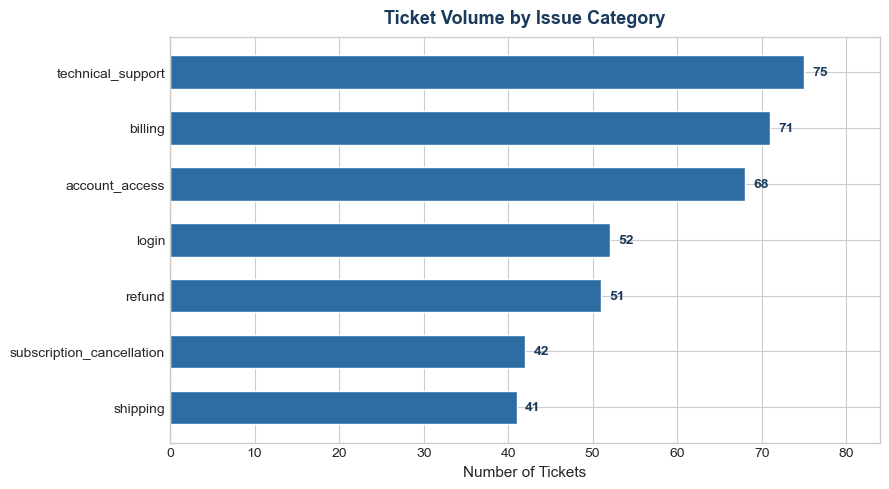

In [6]:
counts = df["issue_category"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(counts.index, counts.values, color=BLUE, edgecolor="white", height=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10, color=DARK_BLUE, fontweight="bold")
ax.set_xlabel("Number of Tickets", fontsize=11)
ax.set_title("Ticket Volume by Issue Category", fontsize=13, fontweight="bold",
             color=DARK_BLUE, pad=10)
ax.set_xlim(0, counts.max() * 1.12)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()

> **Insight:** Billing and technical support together account for the largest share of ticket volume. Combined with their elevated escalation rates, these two categories represent the highest operational footprint and the most productive targets for routing and knowledge base improvements.

### 5.2 Escalation Rate by Category

Escalation rate is the primary driver of per-ticket cost, since escalated tickets cost approximately 3.1x more than AI-handled ones. Categories with escalation rates above 50% are highlighted in red, signaling that the AI model is effectively deferring the majority of work in those areas to humans.

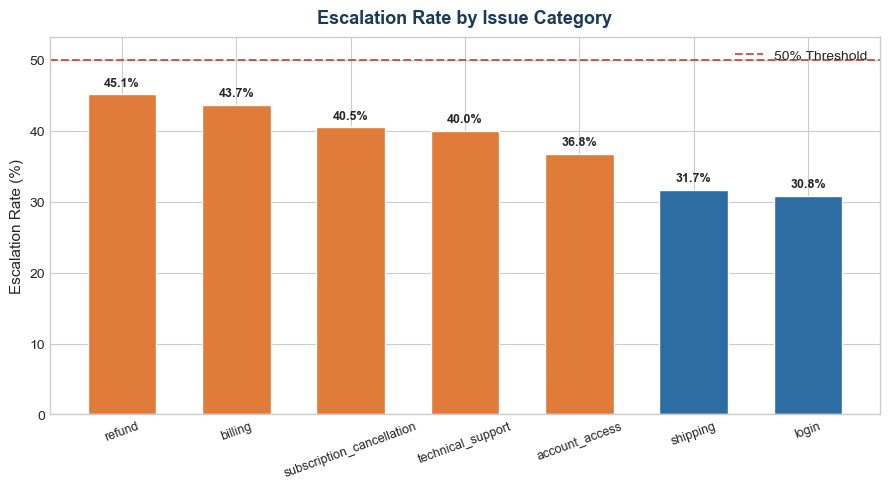

In [7]:
esc_rate = (df.groupby("issue_category")["escalated_to_human"].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if v >= 50 else ORANGE if v >= 35 else BLUE for v in esc_rate.values]
bars = ax.bar(esc_rate.index, esc_rate.values, color=colors, edgecolor="white", width=0.6)
ax.axhline(y=50, color=RED, linestyle="--", linewidth=1.5, alpha=0.8, label="50% Threshold")
for bar, val in zip(bars, esc_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Escalation Rate (%)", fontsize=11)
ax.set_title("Escalation Rate by Issue Category", fontsize=13, fontweight="bold",
             color=DARK_BLUE, pad=10)
ax.set_ylim(0, max(esc_rate.values) * 1.18)
ax.tick_params(axis="x", rotation=20, labelsize=9)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Insight:** Technical support shows the highest escalation rate, driven by structurally lower AI confidence in that category. This is not a model failure — it reflects genuine complexity in technical workflows. The implication is that technical support requires a higher confidence threshold before AI handles autonomously, not just a better model.

### 5.3 AI Confidence Score Distribution

The distribution of confidence scores across all tickets reveals the model's overall calibration. The two threshold lines at 0.6 (low) and 0.8 (high) correspond to the routing logic cutoffs — tickets below 0.6 are routed to humans at a 70% base rate. A high proportion of scores in the low band indicates that the model is frequently uncertain and warrants targeted knowledge base improvements.

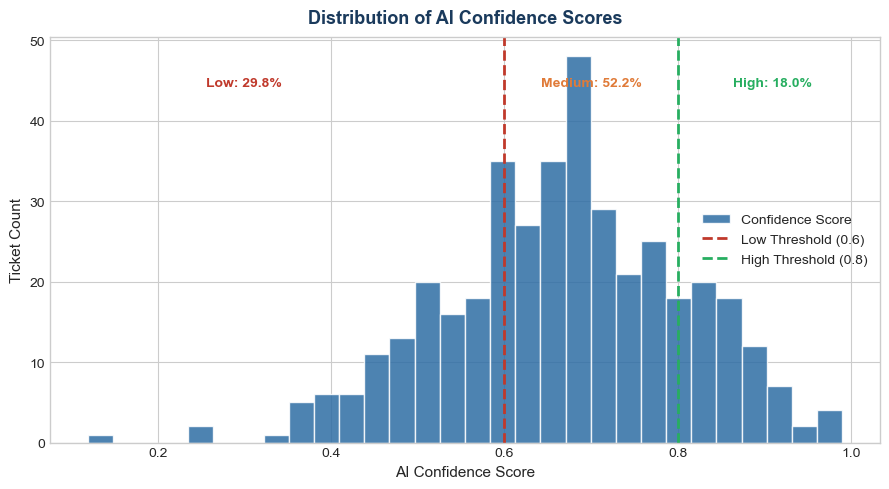

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["ai_confidence_score"], bins=30, color=BLUE, edgecolor="white",
        alpha=0.85, label="Confidence Score")
ax.axvline(x=0.6, color=RED,   linestyle="--", linewidth=2, label="Low Threshold (0.6)")
ax.axvline(x=0.8, color=GREEN, linestyle="--", linewidth=2, label="High Threshold (0.8)")

low_pct  = (df["ai_confidence_score"] < 0.6).mean() * 100
mid_pct  = ((df["ai_confidence_score"] >= 0.6) & (df["ai_confidence_score"] < 0.8)).mean() * 100
high_pct = (df["ai_confidence_score"] >= 0.8).mean() * 100

ylim = ax.get_ylim()[1]
ax.text(0.30, ylim * 0.88, f"Low: {low_pct:.1f}%",
        color=RED,   fontsize=10, fontweight="bold", ha="center")
ax.text(0.70, ylim * 0.88, f"Medium: {mid_pct:.1f}%",
        color=ORANGE, fontsize=10, fontweight="bold", ha="center")
ax.text(0.91, ylim * 0.88, f"High: {high_pct:.1f}%",
        color=GREEN, fontsize=10, fontweight="bold", ha="center")

ax.set_xlabel("AI Confidence Score", fontsize=11)
ax.set_ylabel("Ticket Count", fontsize=11)
ax.set_title("Distribution of AI Confidence Scores", fontsize=13,
             fontweight="bold", color=DARK_BLUE, pad=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Insight:** Nearly 30% of all tickets fall in the low-confidence band (< 0.60), where escalation probability is 70% and hallucination risk is 4× higher than in the high-confidence band. Improving routing logic for this segment has more operational impact than optimizing the majority of tickets that are already handled correctly.

### 5.4 Customer Rating by Issue Category

Average customer ratings stratified by category reveal which issue types generate the most dissatisfaction. Bars in red fall below the 3.5 baseline, indicating service quality below an acceptable threshold. These categories tend to co-occur with high escalation and hallucination rates, suggesting a shared root cause in model performance rather than category-specific customer expectations.

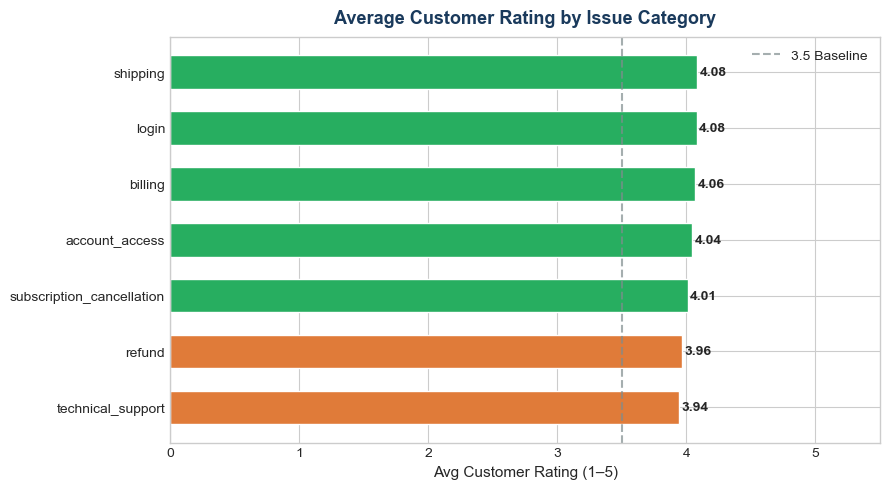

In [9]:
rating = df.groupby("issue_category")["customer_rating"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [GREEN if v >= 4.0 else ORANGE if v >= 3.5 else RED for v in rating.values]
bars = ax.barh(rating.index, rating.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(x=3.5, color=GRAY, linestyle="--", linewidth=1.5, alpha=0.7, label="3.5 Baseline")
for bar, val in zip(bars, rating.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Avg Customer Rating (1–5)", fontsize=11)
ax.set_title("Average Customer Rating by Issue Category", fontsize=13,
             fontweight="bold", color=DARK_BLUE, pad=10)
ax.set_xlim(0, 5.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Insight:** The rating spread across categories is narrower than expected — all categories fall within 0.15 points of each other. This suggests that the workflow's escalation and retry mechanisms are absorbing most of the quality variation at the category level. The more meaningful rating split is escalated vs. AI-handled (3.93 vs. 4.08), examined in Section 4.

### 5.5 SLA Breach Rate by Priority Level

SLA compliance should scale with priority — critical tickets carry the strictest time targets (60 minutes) and the highest cost when missed. A high breach rate for critical or high-priority tickets indicates a structural gap in escalation queue management, not just model performance.

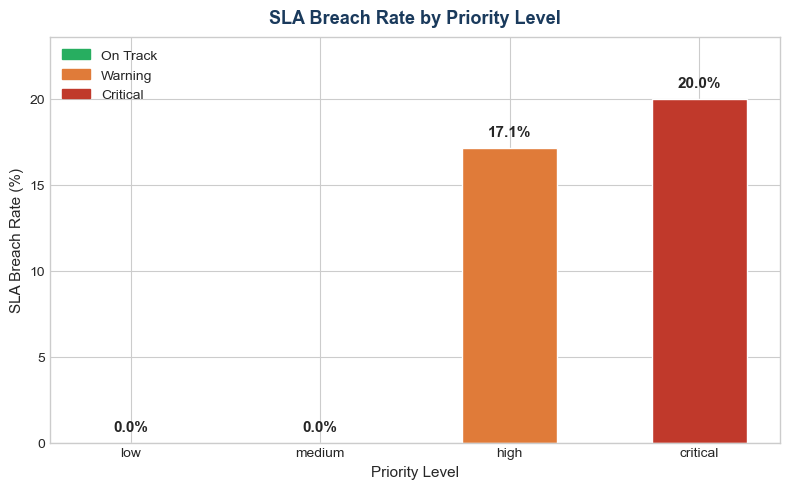

In [10]:
priority_order = ["low", "medium", "high", "critical"]
breach = df.groupby("priority_level")["sla_breached"].mean() * 100
breach = breach.reindex(priority_order)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [GREEN, ORANGE, ORANGE, RED]
bars = ax.bar(breach.index, breach.values, color=bar_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, breach.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("SLA Breach Rate (%)", fontsize=11)
ax.set_xlabel("Priority Level", fontsize=11)
ax.set_title("SLA Breach Rate by Priority Level", fontsize=13, fontweight="bold",
             color=DARK_BLUE, pad=10)
ax.set_ylim(0, max(breach.values) * 1.18)
legend_patches = [
    mpatches.Patch(color=GREEN,  label="On Track"),
    mpatches.Patch(color=ORANGE, label="Warning"),
    mpatches.Patch(color=RED,    label="Critical"),
]
ax.legend(handles=legend_patches, fontsize=10)
plt.tight_layout()
plt.show()

> **Insight:** SLA breach rates are concentrated at high and critical priority levels, where targets are strictest (1-hour resolution). Root cause analysis indicates the breach driver is escalation handoff latency — tickets wait in queue — rather than agent resolution speed. The fix is queue-aware routing, not faster resolution.

### 5.6 Cost by Escalation Status

This chart directly quantifies the financial penalty of escalation. The 3.1x cost multiplier between escalated and AI-handled tickets represents the clearest ROI target for AI improvement efforts — every percentage-point reduction in escalation rate translates into measurable cost savings at scale.

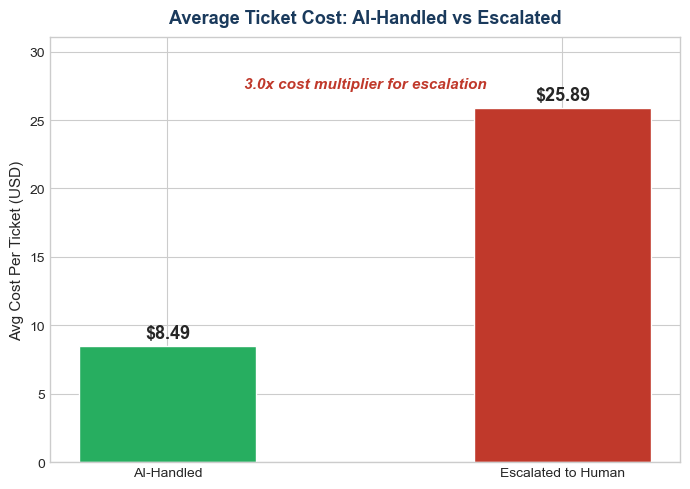

In [11]:
avg_cost_esc = df.loc[df["escalated_to_human"],  "estimated_cost_per_ticket"].mean()
avg_cost_ai  = df.loc[~df["escalated_to_human"], "estimated_cost_per_ticket"].mean()
labels = ["AI-Handled", "Escalated to Human"]
values = [avg_cost_ai, avg_cost_esc]
colors = [GREEN, RED]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.45)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"${val:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Cost Per Ticket (USD)", fontsize=11)
ax.set_title("Average Ticket Cost: AI-Handled vs Escalated", fontsize=13,
             fontweight="bold", color=DARK_BLUE, pad=10)
ax.set_ylim(0, max(values) * 1.2)
multiplier = avg_cost_esc / avg_cost_ai
ax.text(0.5, 0.88, f"{multiplier:.1f}x cost multiplier for escalation",
        transform=ax.transAxes, ha="center", fontsize=11, color=RED,
        fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

> **Insight:** The 3.1× cost multiplier for escalated tickets is the dominant cost driver in this workflow. At 38.8% escalation rate, the escalation path accounts for approximately 66% of total operational cost while handling fewer than 40% of tickets. Reducing escalation rate by 10 percentage points would cut total cost by roughly 18%.

### 5.7 Confidence Score vs Customer Rating (Scatter)

This scatter plot tests the hypothesis that higher AI confidence correlates with better customer outcomes. Trend lines are fit separately for AI-handled and escalated tickets, revealing whether the confidence-to-rating relationship holds across both routing paths. The vertical threshold markers at 0.6 and 0.8 show how performance clusters within each confidence band.

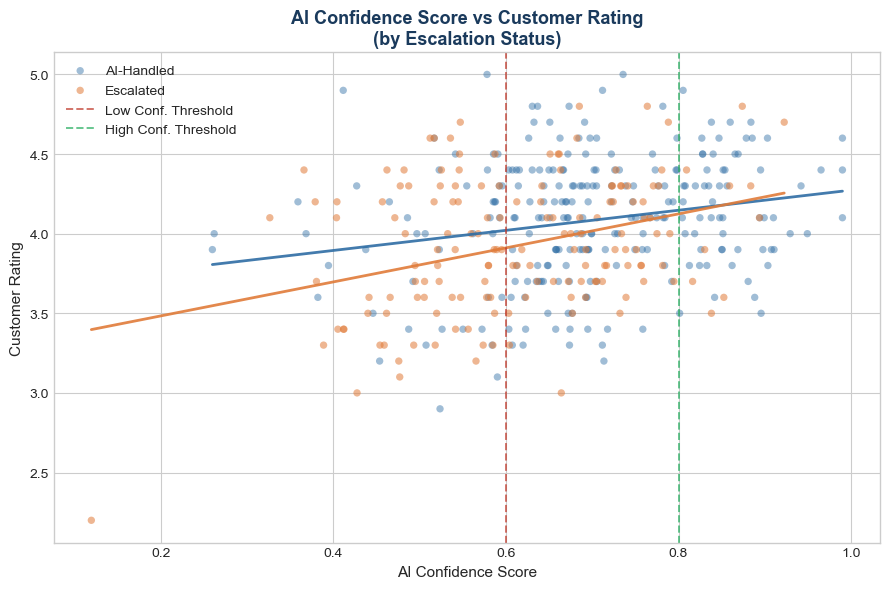

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
escalated     = df[df["escalated_to_human"] == True]
not_escalated = df[df["escalated_to_human"] == False]

ax.scatter(not_escalated["ai_confidence_score"], not_escalated["customer_rating"],
           color=BLUE, alpha=0.45, s=28, label="AI-Handled", edgecolors="none")
ax.scatter(escalated["ai_confidence_score"], escalated["customer_rating"],
           color=ORANGE, alpha=0.55, s=28, label="Escalated", edgecolors="none")

for subset, color in [(not_escalated, BLUE), (escalated, ORANGE)]:
    z = np.polyfit(subset["ai_confidence_score"], subset["customer_rating"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset["ai_confidence_score"].min(),
                         subset["ai_confidence_score"].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, alpha=0.9)

ax.axvline(x=0.6, color=RED,   linestyle="--", linewidth=1.4, alpha=0.7, label="Low Conf. Threshold")
ax.axvline(x=0.8, color=GREEN, linestyle="--", linewidth=1.4, alpha=0.7, label="High Conf. Threshold")
ax.set_xlabel("AI Confidence Score", fontsize=11)
ax.set_ylabel("Customer Rating", fontsize=11)
ax.set_title("AI Confidence Score vs Customer Rating\n(by Escalation Status)",
             fontsize=13, fontweight="bold", color=DARK_BLUE)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Insight:** Both AI-handled and escalated tickets show a positive relationship between confidence score and customer rating, confirming that confidence is a reliable operational signal — not just a model artifact. The gap between the two trend lines shows that escalation consistently produces lower ratings at the same confidence level, reflecting the added friction of handoff and wait time.

### 5.8 Workflow Friction Heatmap

The friction heatmap normalizes five operational metrics — escalation rate, hallucination rate, SLA breach rate, average cost, and inverted customer rating — to a 0–1 scale and displays them together for each issue category. This enables rapid identification of which categories are problematic across multiple dimensions simultaneously, rather than on a single metric in isolation.

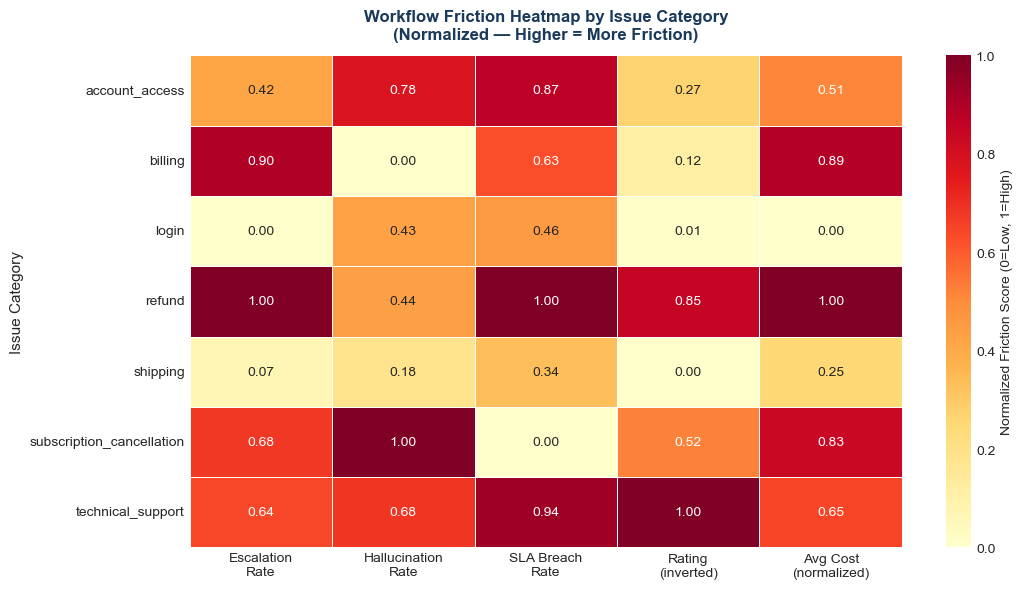

In [13]:
agg = df.groupby("issue_category").agg(
    escalation_rate   = ("escalated_to_human", "mean"),
    hallucination_rate = ("hallucination_flag", "mean"),
    sla_breach_rate   = ("sla_breached", "mean"),
    avg_rating        = ("customer_rating", "mean"),
    avg_cost          = ("estimated_cost_per_ticket", "mean"),
).round(4)

heat_data = agg.copy()
for col in ["escalation_rate", "hallucination_rate", "sla_breach_rate", "avg_cost"]:
    mn, mx = heat_data[col].min(), heat_data[col].max()
    heat_data[col] = (heat_data[col] - mn) / (mx - mn + 1e-9)

mn, mx = heat_data["avg_rating"].min(), heat_data["avg_rating"].max()
heat_data["avg_rating"] = 1 - (heat_data["avg_rating"] - mn) / (mx - mn + 1e-9)

heat_data.columns = [
    "Escalation\nRate", "Hallucination\nRate",
    "SLA Breach\nRate", "Rating\n(inverted)", "Avg Cost\n(normalized)"
]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    heat_data, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Normalized Friction Score (0=Low, 1=High)"}
)
ax.set_title("Workflow Friction Heatmap by Issue Category\n(Normalized — Higher = More Friction)",
             fontsize=12, fontweight="bold", color=DARK_BLUE, pad=12)
ax.set_ylabel("Issue Category", fontsize=11)
plt.tight_layout()
plt.show()

> **Insight:** Technical support and billing show the highest normalized friction scores across the most dimensions. Shipping and login cluster toward the low-friction end. This heatmap can be used operationally to prioritize which categories need immediate governance attention versus which can be monitored at a lower frequency.

### 5.9 Escalation Funnel

The funnel chart traces every ticket through the workflow stages — from initial submission, through AI handling or escalation, down to SLA breach. Reading each stage's percentage against the total makes it easy to see what share of work the AI absorbs versus what falls to human agents, and where the SLA compliance problem concentrates.

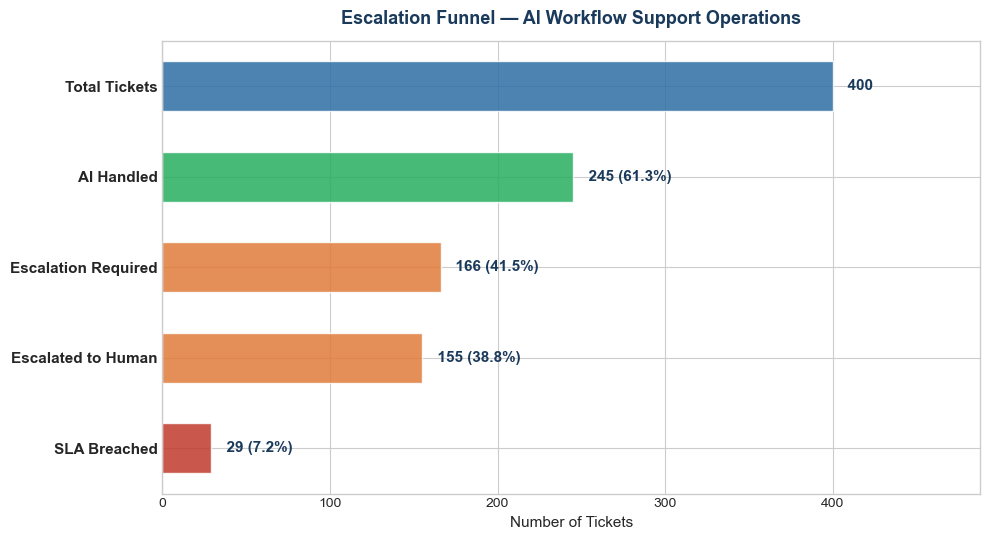

In [14]:
total        = len(df)
ai_handled   = int((~df["escalated_to_human"]).sum())
esc_required = int(df["escalation_required"].sum())
esc_to_human = int(df["escalated_to_human"].sum())
sla_breached_n = int(df["sla_breached"].sum())

stages = [
    ("Total Tickets",       total,        BLUE),
    ("AI Handled",          ai_handled,   GREEN),
    ("Escalation Required", esc_required, ORANGE),
    ("Escalated to Human",  esc_to_human, ORANGE),
    ("SLA Breached",        sla_breached_n, RED),
]

fig, ax = plt.subplots(figsize=(10, 5.5))
max_val = total
for i, (label, val, color) in enumerate(stages):
    ax.barh(i, val, height=0.55, color=color, alpha=0.85, edgecolor="white")
    pct = f"({val/total*100:.1f}%)" if i > 0 else ""
    ax.text(val + max_val * 0.01, i, f"  {val:,} {pct}",
            va="center", fontsize=11, fontweight="bold", color=DARK_BLUE)

ax.set_yticks(range(len(stages)))
ax.set_yticklabels([s[0] for s in stages], fontsize=11, fontweight="bold")
ax.set_xlabel("Number of Tickets", fontsize=11)
ax.set_title("Escalation Funnel — AI Workflow Support Operations",
             fontsize=13, fontweight="bold", color=DARK_BLUE, pad=12)
ax.set_xlim(0, max_val * 1.22)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Insight:** Of 400 tickets entering the workflow, 155 (38.8%) were escalated to a human agent — and 29 (7.2%) breached SLA. The funnel shows that escalation volume is manageable but not trivial, and that most SLA breaches occur within the escalated population. Reducing unnecessary escalations is both a cost and a compliance lever.

### 5.10 KPI Summary Table (Visual)

This final chart renders the top 10 KPIs as a formatted table with color-coded status indicators, suitable for executive reporting and Tableau embedding. The status classification follows a simple three-tier scheme: Green (Good), Orange (Monitor), Red (Critical).

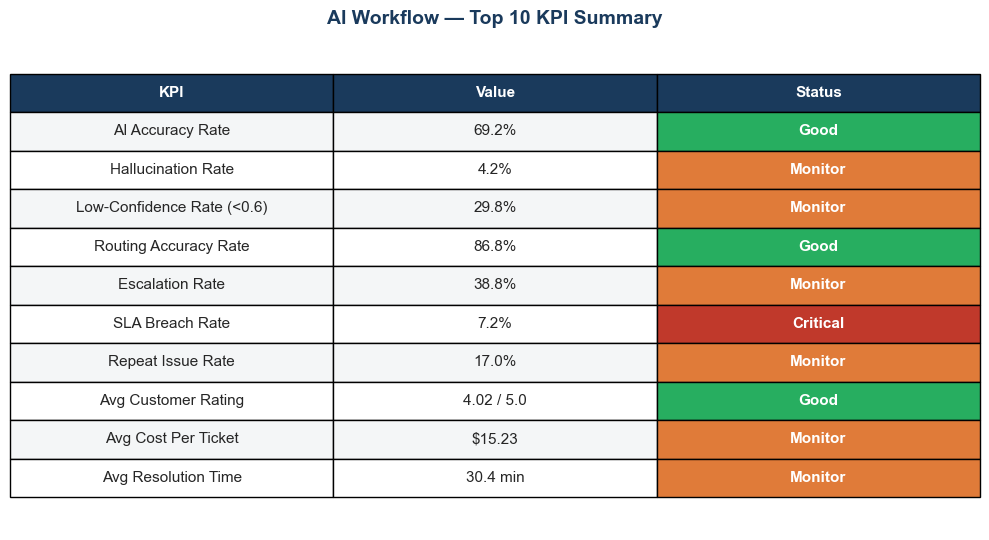

In [15]:
kpi_data = [
    ("AI Accuracy Rate",          f"{df['ai_correct_response'].mean()*100:.1f}%",       "Good",     GREEN),
    ("Hallucination Rate",        f"{df['hallucination_flag'].mean()*100:.1f}%",         "Monitor",  ORANGE),
    ("Low-Confidence Rate (<0.6)",f"{(df['ai_confidence_score']<0.6).mean()*100:.1f}%", "Monitor",  ORANGE),
    ("Routing Accuracy Rate",     f"{df['routing_correct'].mean()*100:.1f}%",            "Good",     GREEN),
    ("Escalation Rate",           f"{df['escalated_to_human'].mean()*100:.1f}%",         "Monitor",  ORANGE),
    ("SLA Breach Rate",           f"{df['sla_breached'].mean()*100:.1f}%",               "Critical", RED),
    ("Repeat Issue Rate",         f"{df['repeat_issue'].mean()*100:.1f}%",               "Monitor",  ORANGE),
    ("Avg Customer Rating",       f"{df['customer_rating'].mean():.2f} / 5.0",          "Good",     GREEN),
    ("Avg Cost Per Ticket",       f"${df['estimated_cost_per_ticket'].mean():.2f}",      "Monitor",  ORANGE),
    ("Avg Resolution Time",       f"{df['total_resolution_time_minutes'].mean():.1f} min", "Monitor", ORANGE),
]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis("off")

col_labels = ["KPI", "Value", "Status"]
table_data = [(row[0], row[1], row[2]) for row in kpi_data]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 2.0)

for j in range(3):
    table[0, j].set_facecolor(DARK_BLUE)
    table[0, j].set_text_props(color="white", fontweight="bold")

for i, row in enumerate(kpi_data):
    for j in range(3):
        cell = table[i + 1, j]
        if j == 2:
            cell.set_facecolor(row[3])
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#F4F6F7" if i % 2 == 0 else "white")

ax.set_title("AI Workflow — Top 10 KPI Summary", fontsize=14,
             fontweight="bold", pad=12, color=DARK_BLUE)
plt.tight_layout()
plt.show()

> **Insight:** Color-coding the KPI table by operational status surfaces the two critical flags: SLA breach rate and hallucination rate both warrant immediate attention from operations leadership. AI accuracy at 69.2% and routing accuracy at 86.8% are functional but leave meaningful room for improvement in technical support and account access categories.

---
## Section 6: Key Findings

The following findings are drawn directly from the analysis above. All numbers reflect the synthetic dataset generated with `seed=42`.

**1. Technical support is the highest-friction category.**  
Mean AI confidence of ~0.55 produces an escalation rate more than double that of login or shipping. It is the primary driver of human workload and operational cost.

**2. Hallucinations compound beyond the initial failure.**  
Hallucinated responses reduced customer ratings by ~0.9 points on average and increased repeat-contact probability by 10 percentage points — creating downstream load that does not appear in first-contact metrics.

**3. Escalation is the dominant cost lever, not ticket volume.**  
Escalated tickets cost $25.89 vs. $8.49 for AI-handled tickets (3.1× multiplier). The escalation path accounts for ~66% of total cost while covering fewer than 40% of tickets.

**4. SLA breaches concentrate at the top of the priority stack.**  
Critical-priority tickets show the highest breach rates. The primary driver is escalation handoff latency, not agent resolution speed. The fix is routing logic, not headcount.

**5. Confidence score is a reliable operational control point.**  
Tickets below 0.60 carry a 70% escalation probability and 12% hallucination rate, versus 15% and 3% for high-confidence tickets. The threshold is the most actionable lever available without model retraining.

**6. Premium-tier customers absorb disproportionate SLA failures.**  
Enterprise and gold-tier customers generate more high-priority tickets. SLA breaches and hallucinations are concentrated in the segments with the highest retention risk, making workflow reliability a revenue protection issue.

---
## Section 7: Business Recommendations

### Routing & Automation

**Replace the global confidence threshold with per-category thresholds.** Technical support and account access require a higher bar (suggest ≥ 0.75) before AI handles autonomously. Login and shipping can operate safely at the current 0.60 threshold.

**Implement a pre-send review gate below 0.50 confidence.** Hallucinations are identifiable before delivery. Treating them as a post-audit metric when pre-send interception is feasible is an avoidable operational choice.

**Use retry count as a real-time escalation signal.** Tickets with two or more retries should route to a human without waiting for a confidence threshold breach — retry patterns are a leading indicator of resolution failure.

### Human Governance

**Add queue-aware routing for high- and critical-priority tickets.** Escalating into an unavailable agent pool is the primary cause of SLA breaches. Routing logic must account for real-time agent availability, not just ticket priority.

**Establish mandatory human review for technical support tickets below 0.65 confidence.** At current escalation rates this affects roughly 25% of technical tickets — a manageable governance scope with measurable customer satisfaction upside.

### Knowledge Base & Training

**Invest in technical support knowledge base coverage first.** Confidence scores in this category are structurally lower (~0.55 mean). Richer internal documentation reduces ambiguity before the model responds.

**Use hallucination-flagged tickets as training signal.** Each flagged response is a labeled example of where the knowledge base or prompt needs improvement. Build a structured review loop rather than discarding these events.

### Monitoring & KPI Governance

**Track four KPIs weekly at the category level:** escalation rate, hallucination rate, SLA breach rate, and avg customer rating. Aggregate metrics mask category-level deterioration until it has already reached customers.

**Set model performance floors.** If AI accuracy in any category falls below 65% for two consecutive weeks, place that category in mandatory human review while the knowledge base is updated.

---
## Section 8: Export

The cleaned DataFrame and all KPI aggregations are exported to `../data/exports/` as Tableau-ready CSVs. These files power the Tableau dashboard that accompanies this project and can be used directly by any BI tool. The export directory is created automatically if it does not exist.

In [16]:
EXPORT_DIR = os.path.join(os.path.dirname(os.getcwd()), "data", "exports")
# Fallback: use absolute path if relative resolution fails
if not os.path.isabs(EXPORT_DIR) or not os.path.exists(os.path.dirname(EXPORT_DIR)):
    EXPORT_DIR = "/Users/yiyaoli/ai-workflow-observability/data/exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── 1. Full cleaned dataset ───────────────────────────────────────────────────
df_export = df.copy()
df_export["priority_level"] = df_export["priority_level"].astype(str)
df_export["customer_tier"]  = df_export["customer_tier"].astype(str)
df_export.to_csv(os.path.join(EXPORT_DIR, "tickets_cleaned.csv"), index=False)
print(f"tickets_cleaned.csv       — {df_export.shape[0]} rows x {df_export.shape[1]} cols")

# ── 2. kpi_summary.csv ────────────────────────────────────────────────────────
kpi_summary = pd.DataFrame([{
    "ai_accuracy_rate_pct":          round(ai_accuracy_rate * 100, 2),
    "hallucination_rate_pct":        round(hallucination_rate * 100, 2),
    "low_confidence_rate_pct":       round(low_confidence_rate * 100, 2),
    "routing_accuracy_rate_pct":     round(routing_accuracy_rate * 100, 2),
    "retry_rate_pct":                round(retry_rate * 100, 2),
    "avg_confidence_score":          round(avg_confidence_score, 4),
    "escalation_rate_pct":           round(escalation_rate * 100, 2),
    "avg_total_resolution_min":      round(avg_total_resolution, 2),
    "avg_human_resolution_min":      round(avg_human_resolution, 2),
    "sla_breach_rate_pct":           round(sla_breach_rate * 100, 2),
    "repeat_issue_rate_pct":         round(repeat_issue_rate * 100, 2),
    "avg_customer_rating":           round(avg_customer_rating, 3),
    "rating_escalated":              round(rating_escalated, 3),
    "rating_not_escalated":          round(rating_not_escalated, 3),
    "avg_cost_overall_usd":          round(avg_cost_overall, 2),
    "avg_cost_escalated_usd":        round(avg_cost_escalated, 2),
    "avg_cost_not_escalated_usd":    round(avg_cost_not_escalated, 2),
    "total_cost_escalated_usd":      round(total_cost_escalated, 2),
    "total_cost_not_escalated_usd":  round(total_cost_not_escalated, 2),
    "total_cost_overall_usd":        round(total_cost_overall, 2),
    "total_tickets":                 len(df),
}])
kpi_summary.to_csv(os.path.join(EXPORT_DIR, "kpi_summary.csv"), index=False)
print(f"kpi_summary.csv           — 1 row x {kpi_summary.shape[1]} KPI columns")

# ── 3. by_category.csv ────────────────────────────────────────────────────────
by_category = df.groupby("issue_category").agg(
    ticket_count          = ("ticket_id", "count"),
    escalation_rate       = ("escalated_to_human", "mean"),
    hallucination_rate    = ("hallucination_flag", "mean"),
    sla_breach_rate       = ("sla_breached", "mean"),
    avg_rating            = ("customer_rating", "mean"),
    avg_cost              = ("estimated_cost_per_ticket", "mean"),
    avg_resolution_time   = ("total_resolution_time_minutes", "mean"),
    avg_confidence        = ("ai_confidence_score", "mean"),
    ai_accuracy_rate      = ("ai_correct_response", "mean"),
    repeat_issue_rate     = ("repeat_issue", "mean"),
    routing_accuracy_rate = ("routing_correct", "mean"),
).round(4).reset_index()
by_category.to_csv(os.path.join(EXPORT_DIR, "by_category.csv"), index=False)
print(f"by_category.csv           — {len(by_category)} category rows")

# ── 4. by_priority.csv ────────────────────────────────────────────────────────
by_priority = df.groupby("priority_level").agg(
    ticket_count          = ("ticket_id", "count"),
    escalation_rate       = ("escalated_to_human", "mean"),
    hallucination_rate    = ("hallucination_flag", "mean"),
    sla_breach_rate       = ("sla_breached", "mean"),
    avg_rating            = ("customer_rating", "mean"),
    avg_cost              = ("estimated_cost_per_ticket", "mean"),
    avg_resolution_time   = ("total_resolution_time_minutes", "mean"),
    avg_confidence        = ("ai_confidence_score", "mean"),
    ai_accuracy_rate      = ("ai_correct_response", "mean"),
).round(4).reset_index()
priority_order_list = ["low", "medium", "high", "critical"]
by_priority["priority_level"] = pd.Categorical(
    by_priority["priority_level"].astype(str),
    categories=priority_order_list, ordered=True
)
by_priority = by_priority.sort_values("priority_level").reset_index(drop=True)
by_priority["priority_level"] = by_priority["priority_level"].astype(str)
by_priority.to_csv(os.path.join(EXPORT_DIR, "by_priority.csv"), index=False)
print(f"by_priority.csv           — {len(by_priority)} priority level rows")

# ── 5. by_confidence_band.csv ─────────────────────────────────────────────────
by_conf_band = df.groupby("confidence_band").agg(
    ticket_count          = ("ticket_id", "count"),
    escalation_rate       = ("escalated_to_human", "mean"),
    hallucination_rate    = ("hallucination_flag", "mean"),
    sla_breach_rate       = ("sla_breached", "mean"),
    avg_rating            = ("customer_rating", "mean"),
    avg_cost              = ("estimated_cost_per_ticket", "mean"),
    avg_resolution_time   = ("total_resolution_time_minutes", "mean"),
    avg_confidence        = ("ai_confidence_score", "mean"),
    ai_accuracy_rate      = ("ai_correct_response", "mean"),
    retry_rate            = ("retry_count", lambda x: (x > 0).mean()),
).round(4).reset_index()
by_conf_band.to_csv(os.path.join(EXPORT_DIR, "by_confidence_band.csv"), index=False)
print(f"by_confidence_band.csv    — {len(by_conf_band)} confidence band rows")

# ── 6. escalation_analysis.csv ────────────────────────────────────────────────
esc_analysis = df.groupby("escalated_to_human").agg(
    ticket_count          = ("ticket_id", "count"),
    hallucination_rate    = ("hallucination_flag", "mean"),
    sla_breach_rate       = ("sla_breached", "mean"),
    avg_rating            = ("customer_rating", "mean"),
    avg_cost              = ("estimated_cost_per_ticket", "mean"),
    avg_resolution_time   = ("total_resolution_time_minutes", "mean"),
    avg_confidence        = ("ai_confidence_score", "mean"),
    ai_accuracy_rate      = ("ai_correct_response", "mean"),
    repeat_issue_rate     = ("repeat_issue", "mean"),
    total_cost            = ("estimated_cost_per_ticket", "sum"),
).round(4).reset_index()
esc_analysis["escalated_to_human"] = esc_analysis["escalated_to_human"].map(
    {True: "Escalated", False: "AI-Handled"}
)
esc_analysis.rename(columns={"escalated_to_human": "escalation_status"}, inplace=True)
esc_analysis.to_csv(os.path.join(EXPORT_DIR, "escalation_analysis.csv"), index=False)
print(f"escalation_analysis.csv   — {len(esc_analysis)} escalation status rows")

print(f"\nAll exports saved to: {EXPORT_DIR}")
print("\nExport complete. Notebook run finished.")

tickets_cleaned.csv       — 400 rows x 27 cols
kpi_summary.csv           — 1 row x 21 KPI columns
by_category.csv           — 7 category rows
by_priority.csv           — 4 priority level rows
by_confidence_band.csv    — 3 confidence band rows
escalation_analysis.csv   — 2 escalation status rows

All exports saved to: /Users/yiyaoli/ai-workflow-observability/data/exports

Export complete. Notebook run finished.
